# Deep Dive Feature Exploration

This notebook performs comprehensive feature analysis on the merged events dataset.

**Important:** SEON scores (fraud_score, blackbox_score, etc.) are **excluded** from model feature recommendations since they represent the benchmark we're trying to beat.

**Goals:**
1. Scan all columns for potential predictive signals (excluding scores)
2. Analyze correlations with fraud label
3. Evaluate SEON benchmark performance vs ground truth (for reference)
4. Identify high-value features for model development
5. Explore feature interactions and patterns

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

DATA_PATH = "../artifacts/merged_events.parquet"

# Display settings
pl.Config.set_tbl_rows(25)
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

## 1. Load and Categorize Features

In [2]:
print(f"Loading {DATA_PATH}...")
df = pl.read_parquet(DATA_PATH)

print(f"Total Columns: {len(df.columns)}")
print(f"Total Rows: {df.height:,}")

# Target column
TARGET_COL = "is_fraud"
assert TARGET_COL in df.columns, f"Target column {TARGET_COL} not found"
print(f"\nFraud Rate: {df[TARGET_COL].mean():.4%}")

Loading ../artifacts/merged_events.parquet...
Total Columns: 230
Total Rows: 732,589

Fraud Rate: 0.9535%


In [3]:
# Categorize columns
schema = df.schema

# ID columns to exclude from analysis
id_cols = ["INSERTION_ID", "INSERTION_ID_hash", "seon_tx_id", "id", "OBJECTREFERENCE"]
id_cols = [c for c in id_cols if c in df.columns]

# Target and benchmark
target_cols = [TARGET_COL, "seon_state", "FLAGGEDFORFRAUD"]
target_cols = [c for c in target_cols if c in df.columns]

# Numeric columns
numeric_types = (pl.Float64, pl.Float32, pl.Int64, pl.Int32, pl.Int16, pl.Int8)
numeric_cols = [c for c in df.columns if schema[c] in numeric_types and c not in id_cols + target_cols]

# Boolean columns
bool_cols = [c for c in df.columns if schema[c] == pl.Boolean]

# Categorical/string columns
cat_cols = [c for c in df.columns if schema[c] == pl.Utf8 and c not in id_cols + target_cols]

# Datetime columns
datetime_cols = [c for c in df.columns if "Datetime" in str(schema[c])]

print(f"\nColumn Categories:")
print(f"  ID columns: {len(id_cols)}")
print(f"  Target/benchmark: {len(target_cols)}")
print(f"  Numeric: {len(numeric_cols)}")
print(f"  Boolean: {len(bool_cols)}")
print(f"  Categorical: {len(cat_cols)}")
print(f"  Datetime: {len(datetime_cols)}")


Column Categories:
  ID columns: 2
  Target/benchmark: 3
  Numeric: 43
  Boolean: 44
  Categorical: 138
  Datetime: 0


## 2. Feature Quality Screening

In [4]:
# Sample for faster analysis
SAMPLE_SIZE = 100000
if df.height > SAMPLE_SIZE:
    df_sample = df.sample(SAMPLE_SIZE, seed=42)
    print(f"Using sample of {SAMPLE_SIZE:,} rows")
else:
    df_sample = df

total_rows = df_sample.height

Using sample of 100,000 rows


In [5]:
# Screen all columns for potential signal
feature_stats = []

print("Scanning columns for feature quality...")

for col in df_sample.columns:
    if col in id_cols or col == TARGET_COL:
        continue
    
    dtype = schema[col]
    
    # 1. Coverage check
    null_count = df_sample[col].null_count()
    coverage = 1.0 - (null_count / total_rows)
    
    if coverage < 0.01:  # Skip if <1% coverage
        continue
    
    # 2. Cardinality check
    n_unique = df_sample[col].n_unique()
    
    # 3. Determine feature type
    is_numeric = dtype in numeric_types
    is_bool = dtype == pl.Boolean
    is_categorical = dtype == pl.Utf8
    
    # 4. Variance check for numeric
    variance = 0.0
    if is_numeric:
        try:
            variance = df_sample[col].var()
            if variance is None or np.isnan(variance) or variance == 0:
                continue
        except:
            continue
    
    # 5. Skip if constant
    if n_unique <= 1:
        continue
    
    # 6. Skip if too unique (likely ID-like)
    if n_unique > total_rows * 0.95 and not is_numeric:
        continue
    
    feature_stats.append({
        "column": col,
        "dtype": str(dtype),
        "coverage": round(coverage, 4),
        "n_unique": n_unique,
        "is_numeric": is_numeric,
        "is_bool": is_bool,
        "is_categorical": is_categorical,
        "variance": variance if is_numeric else None
    })

print(f"\nCandidate features found: {len(feature_stats)}")

# Convert to DataFrame
df_stats = pl.DataFrame(feature_stats).sort("coverage", descending=True)
print(df_stats.head(20))

Scanning columns for feature quality...

Candidate features found: 160
shape: (20, 8)
┌────────────────┬────────┬──────────┬──────────┬────────────┬─────────┬───────────────┬───────────┐
│ column         ┆ dtype  ┆ coverage ┆ n_unique ┆ is_numeric ┆ is_bool ┆ is_categorica ┆ variance  │
│ ---            ┆ ---    ┆ ---      ┆ ---      ┆ ---        ┆ ---     ┆ l             ┆ ---       │
│ str            ┆ str    ┆ f64      ┆ i64      ┆ bool       ┆ bool    ┆ ---           ┆ f64       │
│                ┆        ┆          ┆          ┆            ┆         ┆ bool          ┆           │
╞════════════════╪════════╪══════════╪══════════╪════════════╪═════════╪═══════════════╪═══════════╡
│ AGENCYID       ┆ String ┆ 1.0      ┆ 4        ┆ false      ┆ false   ┆ true          ┆ null      │
│ LISTING_OFFERT ┆ String ┆ 1.0      ┆ 2        ┆ false      ┆ false   ┆ true          ┆ null      │
│ YPE            ┆        ┆          ┆          ┆            ┆         ┆               ┆           │
│ LIS

## 3. Numeric Feature Correlations

In [ ]:
# Get numeric features from screened list - EXCLUDING benchmark/system columns
# Excluded: scores, AUTOAPPROVALCRITERIA_CRITERIA*, FLAGGEDFORFAKECHECK
excluded_patterns = ["score", "seonfraud", "blackbox", "AUTOAPPROVALCRITERIA_CRITERIA", "FLAGGEDFORFAKECHECK"]

def should_exclude(col_name):
    return any(p.lower() in col_name.lower() for p in excluded_patterns)

numeric_candidates = [
    c for c in df_stats.filter(pl.col("is_numeric"))["column"].to_list()
    if not should_exclude(c)
]

print(f"Excluded patterns: {excluded_patterns}")
print(f"Analyzing {len(numeric_candidates)} numeric features (benchmark/system columns excluded)...")

# Calculate correlation with target
correlations = []
y = df_sample[TARGET_COL].to_numpy()

for col in numeric_candidates:
    try:
        x = df_sample[col].fill_null(0).to_numpy()
        
        # Skip if no variance
        if x.std() == 0:
            continue
        
        # Pearson correlation
        corr = np.corrcoef(x, y)[0, 1]
        
        if not np.isnan(corr):
            correlations.append({
                "feature": col,
                "correlation": round(corr, 4),
                "abs_corr": round(abs(corr), 4)
            })
    except Exception as e:
        continue

df_corr = pd.DataFrame(correlations).sort_values("abs_corr", ascending=False)

print(f"\nTop 25 Numeric Features by Correlation with Fraud:")
print(df_corr.head(25).to_string(index=False))

Analyzing 31 numeric features (scores excluded)...

Top 25 Numeric Features by Correlation with Fraud:
                                                         feature  correlation  abs_corr
                                                       LISTINGID      -0.0616    0.0616
                               LISTING_CHARACTERISTICS_YEARBUILT      -0.0569    0.0569
                                      LISTING_LEGACY_PPAPERSONID       0.0556    0.0556
                                         LISTING_LEGACY_PERSONID       0.0556    0.0556
                           LISTING_CHARACTERISTICS_NUMBEROFROOMS      -0.0485    0.0485
                                   SELECTEDBUNDLE_RECURRINGPRICE       0.0476    0.0476
                                     SELECTEDBUNDLE_INITIALPRICE       0.0460    0.0460
                                  SELECTEDBUNDLE_OLDINITIALPRICE       0.0446    0.0446
DATAPIPELINE_SQSMETA_ATTRIBUTES_APPROXIMATEFIRSTRECEIVETIMESTAMP      -0.0398    0.0398
                 

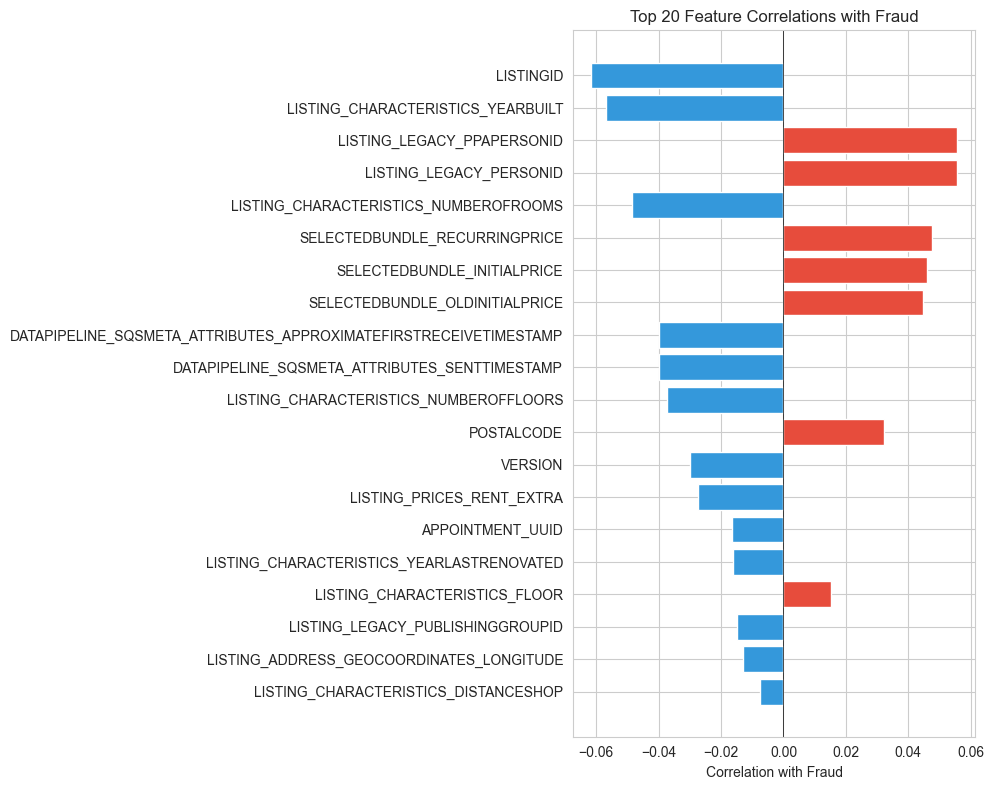

In [7]:
# Visualize top correlations
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_corr = df_corr.head(top_n)

colors = ["#e74c3c" if c > 0 else "#3498db" for c in top_corr["correlation"]]
ax.barh(top_corr["feature"][::-1], top_corr["correlation"][::-1], color=colors[::-1])
ax.axvline(x=0, color="black", linestyle="-", linewidth=0.5)
ax.set_xlabel("Correlation with Fraud")
ax.set_title(f"Top {top_n} Feature Correlations with Fraud")

plt.tight_layout()
plt.show()

## 4. Categorical Feature Analysis

In [8]:
# Get categorical features
cat_candidates = df_stats.filter(pl.col("is_categorical"))["column"].to_list()
bool_candidates = df_stats.filter(pl.col("is_bool"))["column"].to_list()

# Combine categorical-like features
cat_like = cat_candidates + bool_candidates

print(f"Analyzing {len(cat_like)} categorical/boolean features...")

# For each categorical, compute fraud rate spread across categories
cat_results = []
global_fraud_rate = df_sample[TARGET_COL].mean()

for col in cat_like:
    try:
        # Skip very high cardinality
        n_unique = df_sample[col].n_unique()
        if n_unique > 500 and "hash" not in col.lower():
            continue
        
        # Group by category and compute fraud rate
        agg = (
            df_sample.group_by(col)
            .agg([
                pl.len().alias("count"),
                pl.col(TARGET_COL).mean().alias("fraud_rate")
            ])
            .filter(pl.col("count") >= 30)  # Min support
        )
        
        if agg.height < 2:
            continue
        
        # Calculate spread (max - min fraud rate)
        max_rate = agg["fraud_rate"].max()
        min_rate = agg["fraud_rate"].min()
        spread = max_rate - min_rate if max_rate is not None and min_rate is not None else 0
        
        cat_results.append({
            "feature": col,
            "n_categories": agg.height,
            "max_fraud_rate": round(max_rate, 4) if max_rate else 0,
            "min_fraud_rate": round(min_rate, 4) if min_rate else 0,
            "spread": round(spread, 4) if spread else 0
        })
    except Exception as e:
        continue

df_cat = pd.DataFrame(cat_results).sort_values("spread", ascending=False)

print(f"\nTop 25 Categorical Features by Fraud Rate Spread:")
print(df_cat.head(25).to_string(index=False))

Analyzing 123 categorical/boolean features...

Top 25 Categorical Features by Fraud Rate Spread:
                                       feature  n_categories  max_fraud_rate  min_fraud_rate  spread
LISTING_LISTER_CONTACTS_INQUIRY_GIVENNAME_hash            48          0.2333          0.0000  0.2333
                       email/domain/disposable             2          0.2251          0.0089  0.2162
                                        STATUS             9          0.2081          0.0000  0.2081
                                    seon_state             3          0.2060          0.0001  0.2059
                     LISTING_LISTER_EMAIL_hash            46          0.1562          0.0000  0.1562
                                    ip_country            29          0.1407          0.0000  0.1407
  LISTING_LISTER_BILLING_ADDRESS_LOCALITY_hash           614          0.0833          0.0000  0.0833
                 LISTING_ADDRESS_LOCALITY_hash           689          0.0833          0.0000  0

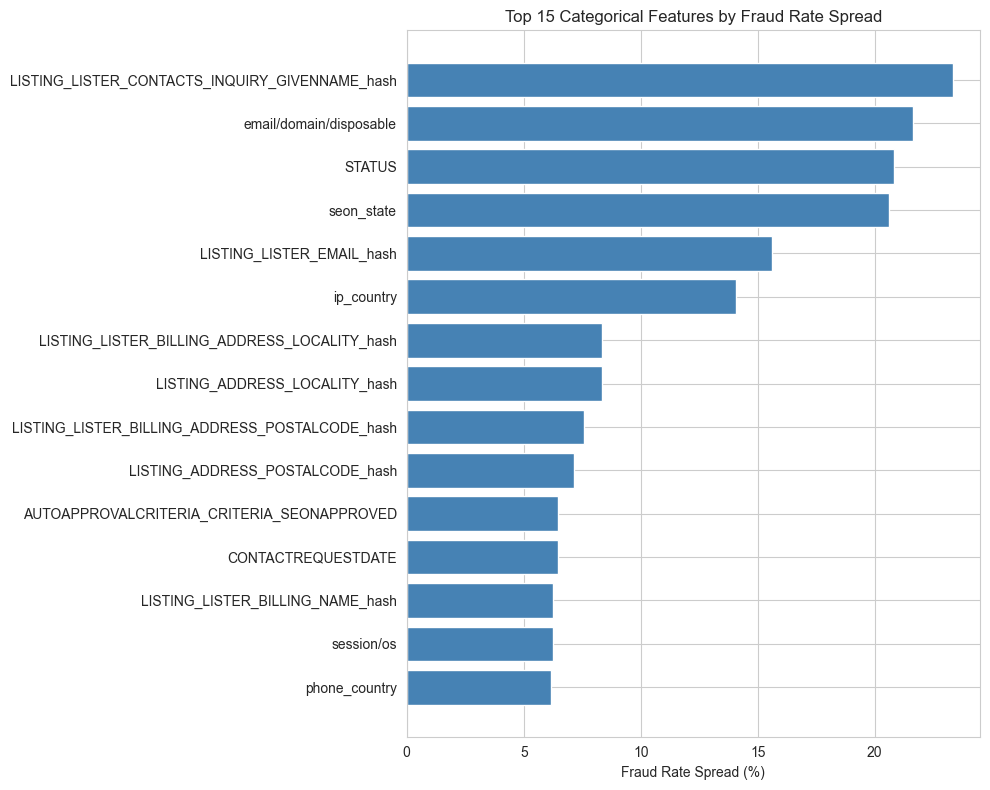

In [9]:
# Visualize top categorical features
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 15
top_cat = df_cat.head(top_n)

ax.barh(top_cat["feature"][::-1], top_cat["spread"][::-1] * 100, color="steelblue")
ax.set_xlabel("Fraud Rate Spread (%)")
ax.set_title(f"Top {top_n} Categorical Features by Fraud Rate Spread")

plt.tight_layout()
plt.show()

## 5. SEON Benchmark Evaluation

In [10]:
# Detailed analysis of SEON state vs actual fraud
benchmark_col = "seon_state"

if benchmark_col in df_sample.columns:
    # Distribution
    state_analysis = (
        df_sample.group_by(benchmark_col)
        .agg([
            pl.len().alias("count"),
            pl.col(TARGET_COL).sum().alias("fraud_count"),
            pl.col(TARGET_COL).mean().alias("fraud_rate")
        ])
        .sort("count", descending=True)
        .with_columns([
            (pl.col("count") / total_rows * 100).round(2).alias("pct_of_total"),
            (pl.col("fraud_rate") * 100).round(2).alias("fraud_rate_pct")
        ])
    )
    
    print("SEON State Distribution and Fraud Rates:")
    print(state_analysis)

SEON State Distribution and Fraud Rates:
shape: (3, 6)
┌────────────┬───────┬─────────────┬────────────┬──────────────┬────────────────┐
│ seon_state ┆ count ┆ fraud_count ┆ fraud_rate ┆ pct_of_total ┆ fraud_rate_pct │
│ ---        ┆ ---   ┆ ---         ┆ ---        ┆ ---          ┆ ---            │
│ str        ┆ u32   ┆ i64         ┆ f64        ┆ f64          ┆ f64            │
╞════════════╪═══════╪═════════════╪════════════╪══════════════╪════════════════╡
│ APPROVE    ┆ 86278 ┆ 6           ┆ 0.00007    ┆ 86.28        ┆ 0.01           │
│ REVIEW     ┆ 9100  ┆ 1           ┆ 0.00011    ┆ 9.1          ┆ 0.01           │
│ DECLINE    ┆ 4622  ┆ 952         ┆ 0.205971   ┆ 4.62         ┆ 20.6           │
└────────────┴───────┴─────────────┴────────────┴──────────────┴────────────────┘


In [11]:
# Confusion matrix for SEON predictions
if benchmark_col in df_sample.columns:
    # Define what SEON considers "fraud"
    # DECLINE, BLOCK, MANUAL_REVIEW typically indicate suspected fraud
    fraud_states = ["DECLINE", "BLOCK"]
    review_states = ["MANUAL_REVIEW"]
    approve_states = ["APPROVE"]
    
    df_eval = df_sample.with_columns(
        pl.when(pl.col(benchmark_col).is_in(fraud_states))
        .then(pl.lit("DECLINE/BLOCK"))
        .when(pl.col(benchmark_col).is_in(review_states))
        .then(pl.lit("REVIEW"))
        .when(pl.col(benchmark_col).is_in(approve_states))
        .then(pl.lit("APPROVE"))
        .otherwise(pl.lit("OTHER"))
        .alias("seon_decision")
    )
    
    # Cross-tab
    decision_fraud = (
        df_eval.group_by(["seon_decision", TARGET_COL])
        .len()
        .pivot(on=TARGET_COL, index="seon_decision", values="len")
        .rename({"0": "Actual_NonFraud", "1": "Actual_Fraud"})
    )
    
    print("\nSEON Decision vs Actual Fraud:")
    print(decision_fraud)


SEON Decision vs Actual Fraud:
shape: (3, 3)
┌───────────────┬─────────────────┬──────────────┐
│ seon_decision ┆ Actual_NonFraud ┆ Actual_Fraud │
│ ---           ┆ ---             ┆ ---          │
│ str           ┆ u32             ┆ u32          │
╞═══════════════╪═════════════════╪══════════════╡
│ DECLINE/BLOCK ┆ 3670            ┆ 952          │
│ APPROVE       ┆ 86272           ┆ 6            │
│ OTHER         ┆ 9099            ┆ 1            │
└───────────────┴─────────────────┴──────────────┘


In [12]:
# Calculate missed fraud and false positives
if benchmark_col in df_sample.columns:
    # Events that SEON approved but were fraud
    missed_fraud = df_eval.filter(
        (pl.col("seon_decision") == "APPROVE") & 
        (pl.col(TARGET_COL) == 1)
    ).height
    
    # Events that SEON declined but were not fraud
    false_positives = df_eval.filter(
        (pl.col("seon_decision") == "DECLINE/BLOCK") & 
        (pl.col(TARGET_COL) == 0)
    ).height
    
    total_fraud = df_eval.filter(pl.col(TARGET_COL) == 1).height
    total_non_fraud = df_eval.filter(pl.col(TARGET_COL) == 0).height
    
    print(f"\nSEON Benchmark Performance Issues:")
    print(f"  Missed Fraud (APPROVE -> Fraud): {missed_fraud:,} ({missed_fraud/total_fraud*100:.1f}% of all fraud)")
    print(f"  False Positives (DECLINE/BLOCK -> Non-Fraud): {false_positives:,} ({false_positives/total_non_fraud*100:.1f}% of non-fraud)")


SEON Benchmark Performance Issues:
  Missed Fraud (APPROVE -> Fraud): 6 (0.6% of all fraud)
  False Positives (DECLINE/BLOCK -> Non-Fraud): 3,670 (3.7% of non-fraud)


## 6. SEON Score Analysis (Benchmark Reference Only)

> **Note:** SEON scores are shown for reference to understand the benchmark. They are **NOT** used as model features.

⚠️  SEON Scores shown for BENCHMARK REFERENCE only - NOT used as model features


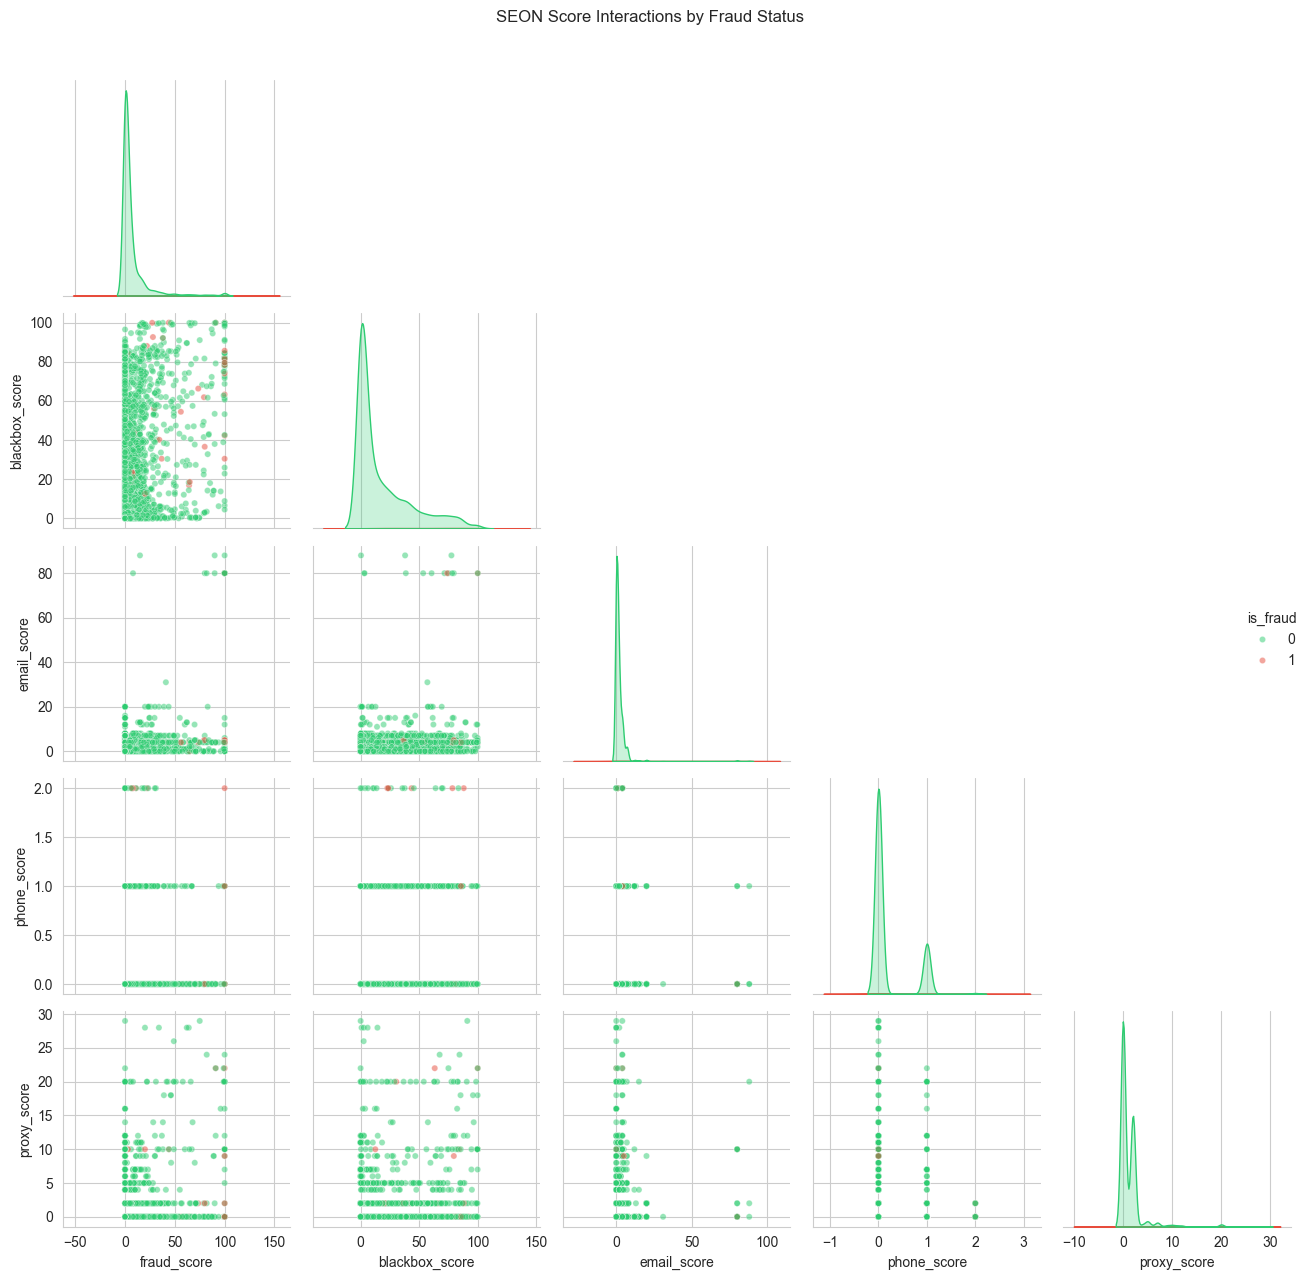

In [13]:
# Analyze SEON score interactions (BENCHMARK REFERENCE ONLY - not used as features)
print("⚠️  SEON Scores shown for BENCHMARK REFERENCE only - NOT used as model features")
benchmark_score_cols = [c for c in ["fraud_score", "blackbox_score", "email_score", "phone_score", "proxy_score"] 
                        if c in df_sample.columns]

if len(benchmark_score_cols) >= 2:
    # Pairplot of score features by fraud status (benchmark reference)
    plot_df = df_sample.select(benchmark_score_cols + [TARGET_COL]).drop_nulls().to_pandas()
    
    # Sample for plotting
    if len(plot_df) > 5000:
        plot_df = plot_df.sample(5000, random_state=42)
    
    g = sns.pairplot(
        plot_df,
        hue=TARGET_COL,
        palette={0: "#2ecc71", 1: "#e74c3c"},
        diag_kind="kde",
        plot_kws={"alpha": 0.5, "s": 20},
        corner=True
    )
    g.fig.suptitle("SEON Score Interactions by Fraud Status", y=1.02)
    plt.tight_layout()
    plt.show()

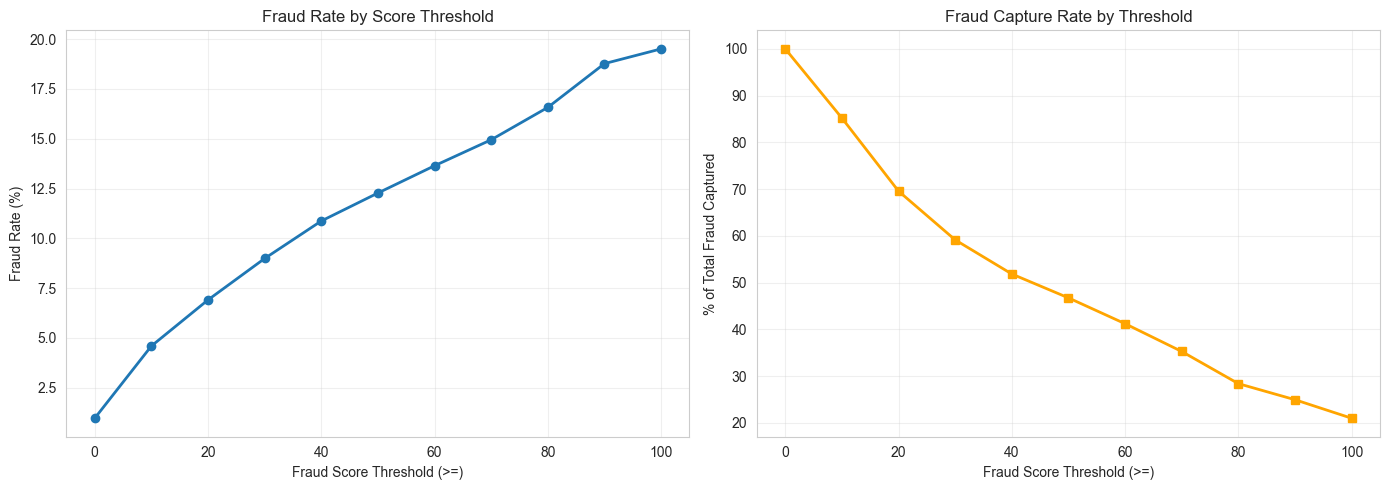


Threshold Analysis:
 threshold  count  fraud_rate  pct_of_fraud
         0 100000      0.0096        1.0000
        10  17813      0.0459        0.8519
        20   9662      0.0690        0.6955
        30   6311      0.0898        0.5912
        40   4573      0.1087        0.5182
        50   3650      0.1227        0.4672
        60   2895      0.1364        0.4119
        70   2261      0.1495        0.3525
        80   1641      0.1658        0.2836
        90   1273      0.1877        0.2492
       100   1030      0.1951        0.2096


In [14]:
# Score thresholds analysis
if "fraud_score" in df_sample.columns:
    # Analyze fraud rate at different score thresholds
    thresholds = list(range(0, 101, 10))
    threshold_analysis = []
    
    for thresh in thresholds:
        above = df_sample.filter(pl.col("fraud_score") >= thresh)
        if above.height > 0:
            fraud_rate = above[TARGET_COL].mean()
            threshold_analysis.append({
                "threshold": thresh,
                "count": above.height,
                "fraud_rate": fraud_rate,
                "pct_of_fraud": above.filter(pl.col(TARGET_COL) == 1).height / 
                               df_sample.filter(pl.col(TARGET_COL) == 1).height
            })
    
    df_thresh = pd.DataFrame(threshold_analysis)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    ax1 = axes[0]
    ax1.plot(df_thresh["threshold"], df_thresh["fraud_rate"] * 100, marker="o", linewidth=2)
    ax1.set_xlabel("Fraud Score Threshold (>=)")
    ax1.set_ylabel("Fraud Rate (%)")
    ax1.set_title("Fraud Rate by Score Threshold")
    ax1.grid(True, alpha=0.3)
    
    ax2 = axes[1]
    ax2.plot(df_thresh["threshold"], df_thresh["pct_of_fraud"] * 100, marker="s", linewidth=2, color="orange")
    ax2.set_xlabel("Fraud Score Threshold (>=)")
    ax2.set_ylabel("% of Total Fraud Captured")
    ax2.set_title("Fraud Capture Rate by Threshold")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    print("\nThreshold Analysis:")
    print(df_thresh.round(4).to_string(index=False))

## 7. Summary: Top Features for Modeling

In [15]:
# Compile comprehensive feature rankings
print("="*70)
print("FEATURE ANALYSIS SUMMARY")
print("="*70)
print("\n⚠️  SEON scores EXCLUDED from model features (benchmark only)")

# Top numeric features (non-score)
print("\n📊 TOP NUMERIC FEATURES (by correlation, scores excluded):")
for i, (_, row) in enumerate(df_corr.head(10).iterrows()):
    direction = "⬆️" if row["correlation"] > 0 else "⬇️"
    print(f"   {i+1}. {row['feature']:40s} {direction} {row['correlation']:+.4f}")

# Top categorical features
print("\n🏷️ TOP CATEGORICAL FEATURES (by fraud rate spread):")
for i, (_, row) in enumerate(df_cat.head(10).iterrows()):
    print(f"   {i+1}. {row['feature']:40s} spread: {row['spread']*100:.1f}%")

# SEON benchmark insights
if benchmark_col in df_sample.columns:
    print("\n🎯 SEON BENCHMARK INSIGHTS (Reference Only):")
    print(f"   - Missed Fraud Rate: {missed_fraud/total_fraud*100:.1f}%")
    print(f"   - False Positive Rate: {false_positives/total_non_fraud*100:.2f}%")

# Recommendations
print("\n💡 RECOMMENDATIONS:")
print("   1. Focus on boolean/categorical features (email, phone, IP attributes)")
print("   2. SEON scores are EXCLUDED - they represent the benchmark to beat")
print("   3. IP/email/phone domain features show significant signal")
print("   4. SEON benchmark misses some fraud - opportunity for improvement")
print("="*70)

FEATURE ANALYSIS SUMMARY

⚠️  SEON scores EXCLUDED from model features (benchmark only)

📊 TOP NUMERIC FEATURES (by correlation, scores excluded):
   1. LISTINGID                                ⬇️ -0.0616
   2. LISTING_CHARACTERISTICS_YEARBUILT        ⬇️ -0.0569
   3. LISTING_LEGACY_PPAPERSONID               ⬆️ +0.0556
   4. LISTING_LEGACY_PERSONID                  ⬆️ +0.0556
   5. LISTING_CHARACTERISTICS_NUMBEROFROOMS    ⬇️ -0.0485
   6. SELECTEDBUNDLE_RECURRINGPRICE            ⬆️ +0.0476
   7. SELECTEDBUNDLE_INITIALPRICE              ⬆️ +0.0460
   8. SELECTEDBUNDLE_OLDINITIALPRICE           ⬆️ +0.0446
   9. DATAPIPELINE_SQSMETA_ATTRIBUTES_APPROXIMATEFIRSTRECEIVETIMESTAMP ⬇️ -0.0398
   10. DATAPIPELINE_SQSMETA_ATTRIBUTES_SENTTIMESTAMP ⬇️ -0.0398

🏷️ TOP CATEGORICAL FEATURES (by fraud rate spread):
   1. LISTING_LISTER_CONTACTS_INQUIRY_GIVENNAME_hash spread: 23.3%
   2. email/domain/disposable                  spread: 21.6%
   3. STATUS                                   spread: 20.8%
 

In [16]:
# Export top features for modeling (EXCLUDING SEON scores)
top_features = {
    "numeric": df_corr.head(20)["feature"].tolist(),  # Already excludes scores
    "categorical": df_cat.head(10)["feature"].tolist(),
    "excluded_benchmark": benchmark_score_cols  # For reference only
}

print("\nRecommended Features for Modeling (scores EXCLUDED):")
print(f"  Numeric ({len(top_features['numeric'])}): {top_features['numeric'][:5]}...")
print(f"  Categorical ({len(top_features['categorical'])}): {top_features['categorical'][:5]}...")
print(f"\n⚠️  EXCLUDED (benchmark only): {top_features['excluded_benchmark']}")


Recommended Features for Modeling (scores EXCLUDED):
  Numeric (20): ['LISTINGID', 'LISTING_CHARACTERISTICS_YEARBUILT', 'LISTING_LEGACY_PPAPERSONID', 'LISTING_LEGACY_PERSONID', 'LISTING_CHARACTERISTICS_NUMBEROFROOMS']...
  Categorical (10): ['LISTING_LISTER_CONTACTS_INQUIRY_GIVENNAME_hash', 'email/domain/disposable', 'STATUS', 'seon_state', 'LISTING_LISTER_EMAIL_hash']...

⚠️  EXCLUDED (benchmark only): ['fraud_score', 'blackbox_score', 'email_score', 'phone_score', 'proxy_score']
